# Comparação final dos quatro modelos

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import display, Image

here = Path.cwd().resolve()
group = next(
    (p for p in [here, *here.parents] if (p / "config.py").exists() and (p / "lib").is_dir()),
    None,
)
if group is None:
    raise RuntimeError("Não encontrei analyses/grupo2. Abra o notebook dentro do projeto.")
if str(group) not in sys.path:
    sys.path.insert(0, str(group))

import config
from lib import data as data_lib, features, eda_stl
from lib import models_v2 as models
from lib.nb_boot import require_file, save_json, load_json
data_lib.ensure_output_dirs()
print("outputs →", config.OUTPUT_DIR)


outputs → C:\Users\brunacardoso-ieg\OneDrive - Instituto Germinare\Área de Trabalho\Tech\Séries Temporais\trabalho_PLS_grupo2\pls-regration-comparation\analyses\grupo2\outputs


,model,n_forecasts,mae,rmse,median_absolute_error,wape_percent,bias,r2,residual_acf_lag1,fallback_count,convergence_rate,runtime_sec,mean_seconds_per_origin,ljung_box_pvalue_sampled_sequence_lag24,rank,improvement_vs_best_baseline_percent
0,Random_Forest,521,157.762165,255.579959,101.314444,4.698163,13.810119,0.983706,0.117825,0,1.000000,1804.033284,3.462636,0.023163,1,44.315212
1,PLS_Regression,521,191.695971,292.390864,135.063968,5.708714,2.407503,0.978674,0.004962,0,1.000000,8.905334,0.017093,0.038742,2,32.337709
2,Holt_Winters,521,209.833313,368.724579,115.000000,6.248844,-4.263386,0.966085,0.094886,167,0.681382,25.420279,0.048791,0.000019,3,25.935832
3,SARIMAX,521,263.678420,375.030274,179.412630,7.852354,-11.796178,0.964915,-0.001774,0,0.834933,27940.137767,53.627904,0.033984,4,6.930303


Random_Forest


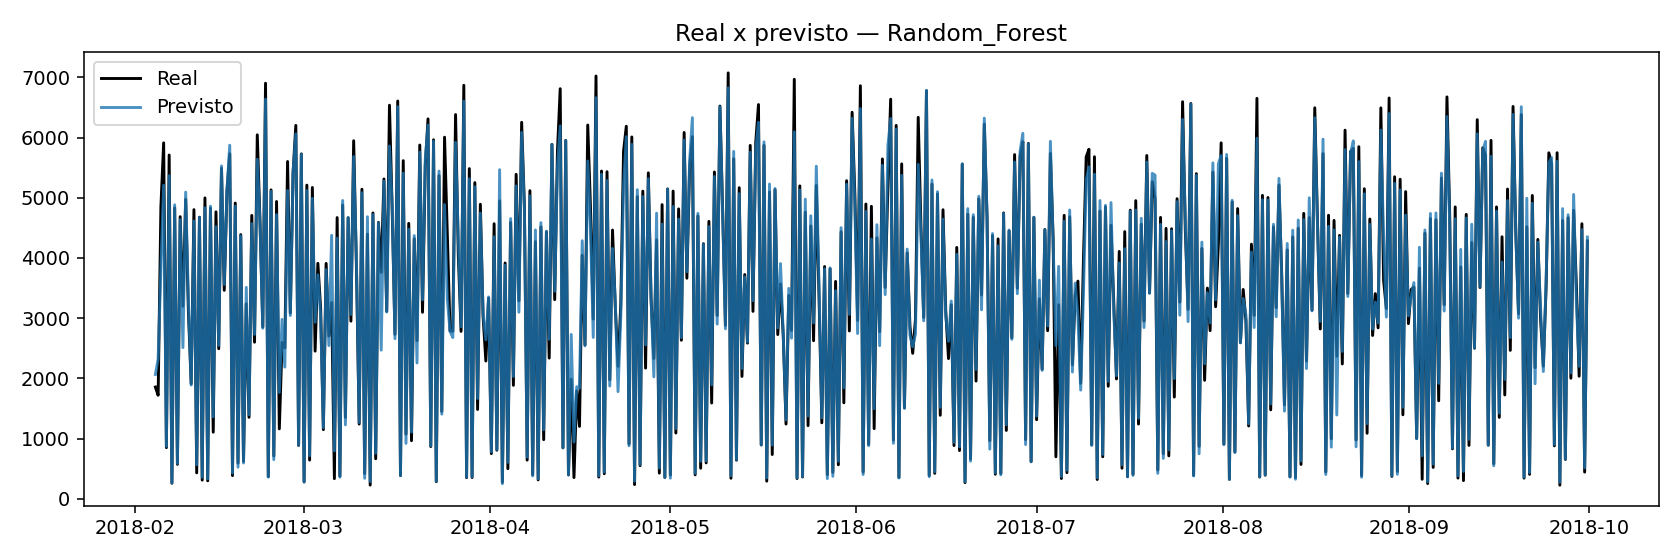

PLS_Regression


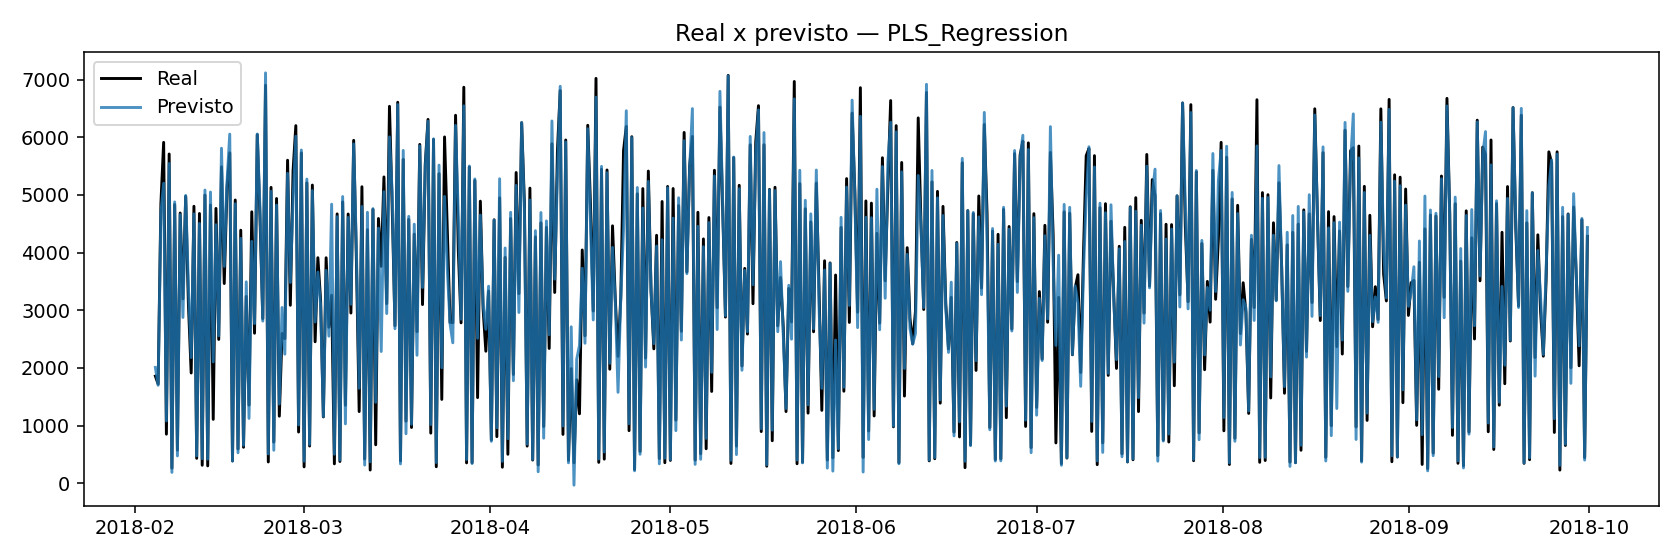

Holt_Winters


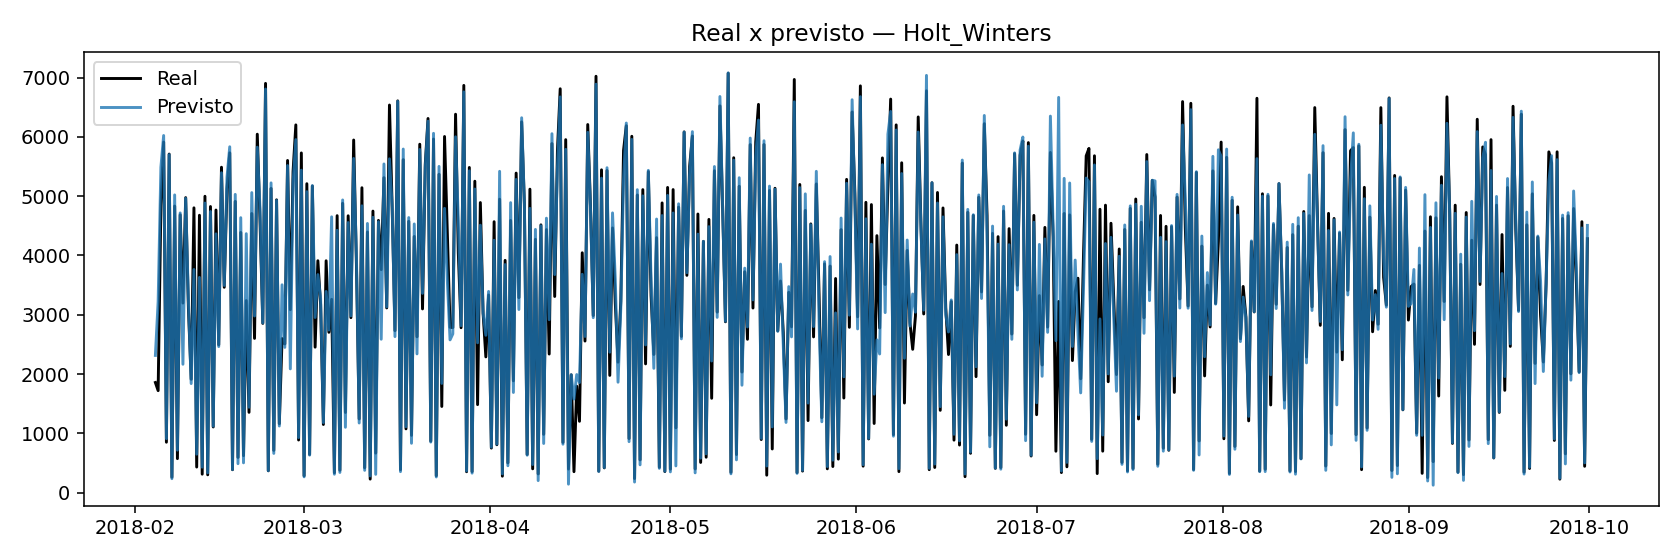

SARIMAX


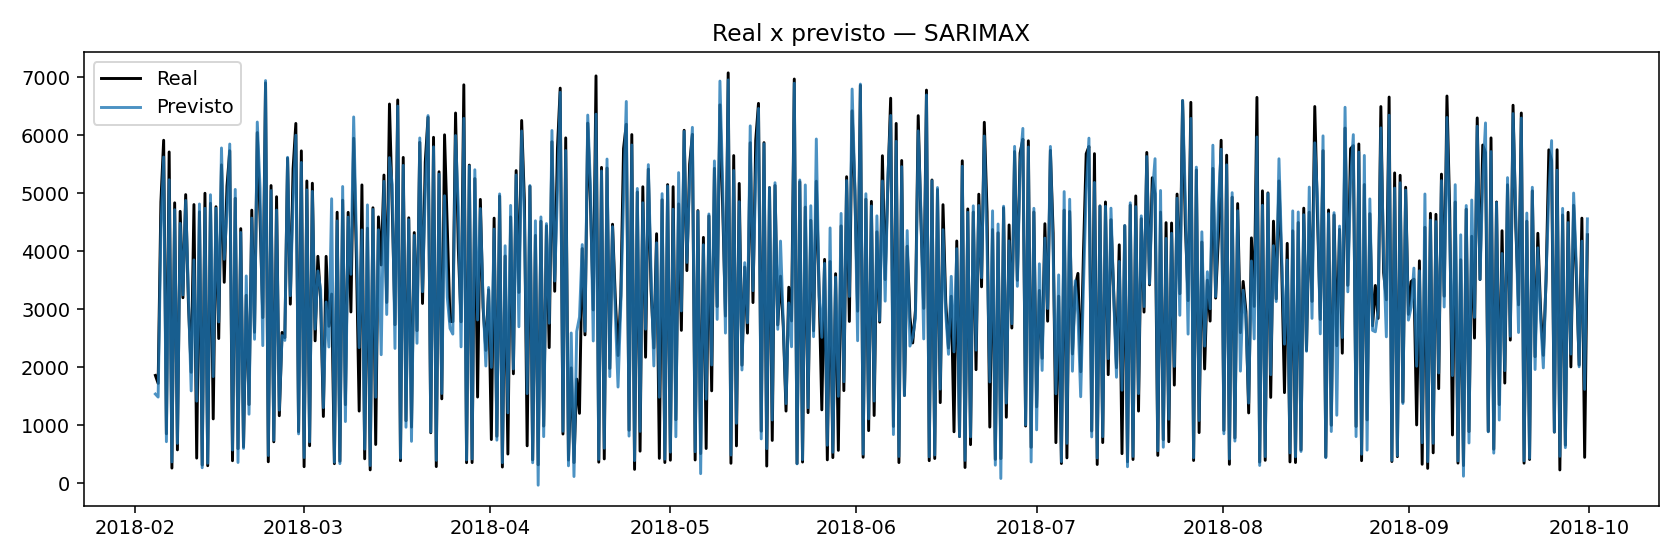

In [2]:
mae = pd.read_csv(require_file(
    config.RESULT_DIR / "mae_consolidado.csv", "01_MAE_consolidado.ipynb"
))
display(mae)
for model in mae["model"]:
    path = config.FIG_DIR / f"previsao_{model}.png"
    if path.exists():
        print(model)
        display(Image(filename=str(path)))


In [3]:
# Incerteza do MAE: bootstrap em blocos de 7 origens.
rng = np.random.default_rng(config.RANDOM_STATE)
errors = {}
for model in mae["model"]:
    pred = pd.read_csv(
        config.RESULT_DIR / f"predictions_{model}.csv",
        parse_dates=["target_date"],
    )
    errors[model] = (pred["y_true"] - pred["y_pred"]).abs().to_numpy()

def block_sample(n, block=7):
    starts = rng.integers(0, n, size=int(np.ceil(n / block)))
    return np.concatenate([
        np.arange(start, start + block) % n for start in starts
    ])[:n]

ci_rows = []
for model, values in errors.items():
    samples = np.array([
        values[block_sample(len(values))].mean() for _ in range(5000)
    ])
    ci_rows.append({
        "model": model,
        "mae": values.mean(),
        "mae_ci95_low": np.quantile(samples, 0.025),
        "mae_ci95_high": np.quantile(samples, 0.975),
    })
ci = pd.DataFrame(ci_rows).sort_values("mae")
ci.to_csv(config.RESULT_DIR / "mae_uncertainty.csv", index=False)
display(ci)


,model,mae,mae_ci95_low,mae_ci95_high
0,Random_Forest,157.762165,139.584168,176.790227
1,PLS_Regression,191.695971,173.163215,213.365706
2,Holt_Winters,209.833313,180.540424,243.570374
3,SARIMAX,263.678420,242.740636,286.661162
